In [2]:
# Cell 1：基本统计 + 偏度
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy import stats

matplotlib.rcParams['font.family'] = 'Microsoft YaHei'

df = pd.read_excel('df_cleaned.xlsx')

features = ['Si','Fe','Cu','Mn','Mg','Cr','Zn','V','Ti','Zr',
            'Li','Ni','Be','Sc','Tsol','Tage','tage']
targets  = ['YS', 'UTS', 'El']

# 基本统计
print("基本统计描述：")
print(df[features + targets].describe().round(3))

# 变异系数
print("\n变异系数（CV < 0.1 说明几乎没变化）：")
cv = (df[features + targets].std() / df[features + targets].mean()).round(3)
print(cv.sort_values())
low_var = cv[cv < 0.1].index.tolist()
if low_var:
    print(f"\n⚠️ 低变异特征: {low_var}")

# 偏度
print("\n偏度统计（|skew| > 1 为明显偏态）：")
skewness = df[features + targets].skew().round(3).sort_values(ascending=False)
print(skewness)
print(f"\n明显偏态: {skewness[abs(skewness) > 1].index.tolist()}")

基本统计描述：
            Si       Fe       Cu       Mn       Mg       Cr       Zn        V  \
count  320.000  320.000  320.000  320.000  320.000  320.000  320.000  320.000   
mean     1.612    0.206    2.314    0.216    1.378    0.038    3.426    0.003   
std      3.744    0.218    1.950    0.265    0.752    0.061    3.403    0.017   
min      0.000    0.000    0.000    0.000    0.000    0.000    0.000    0.000   
25%      0.010    0.020    0.330    0.000    0.600    0.000    0.030    0.000   
50%      0.115    0.110    1.550    0.100    1.580    0.001    4.600    0.000   
75%      0.644    0.378    4.410    0.320    1.965    0.050    6.940    0.000   
max     12.250    1.100    6.500    1.310    2.800    0.260    7.900    0.158   

            Ti       Zr     Li       Ni       Be       Sc     Tsol     Tage  \
count  320.000  320.000  320.0  320.000  320.000  320.000  320.000  320.000   
mean     0.031    0.060    0.0    0.033    0.000    0.036  492.751  154.493   
std      0.047    0.069  

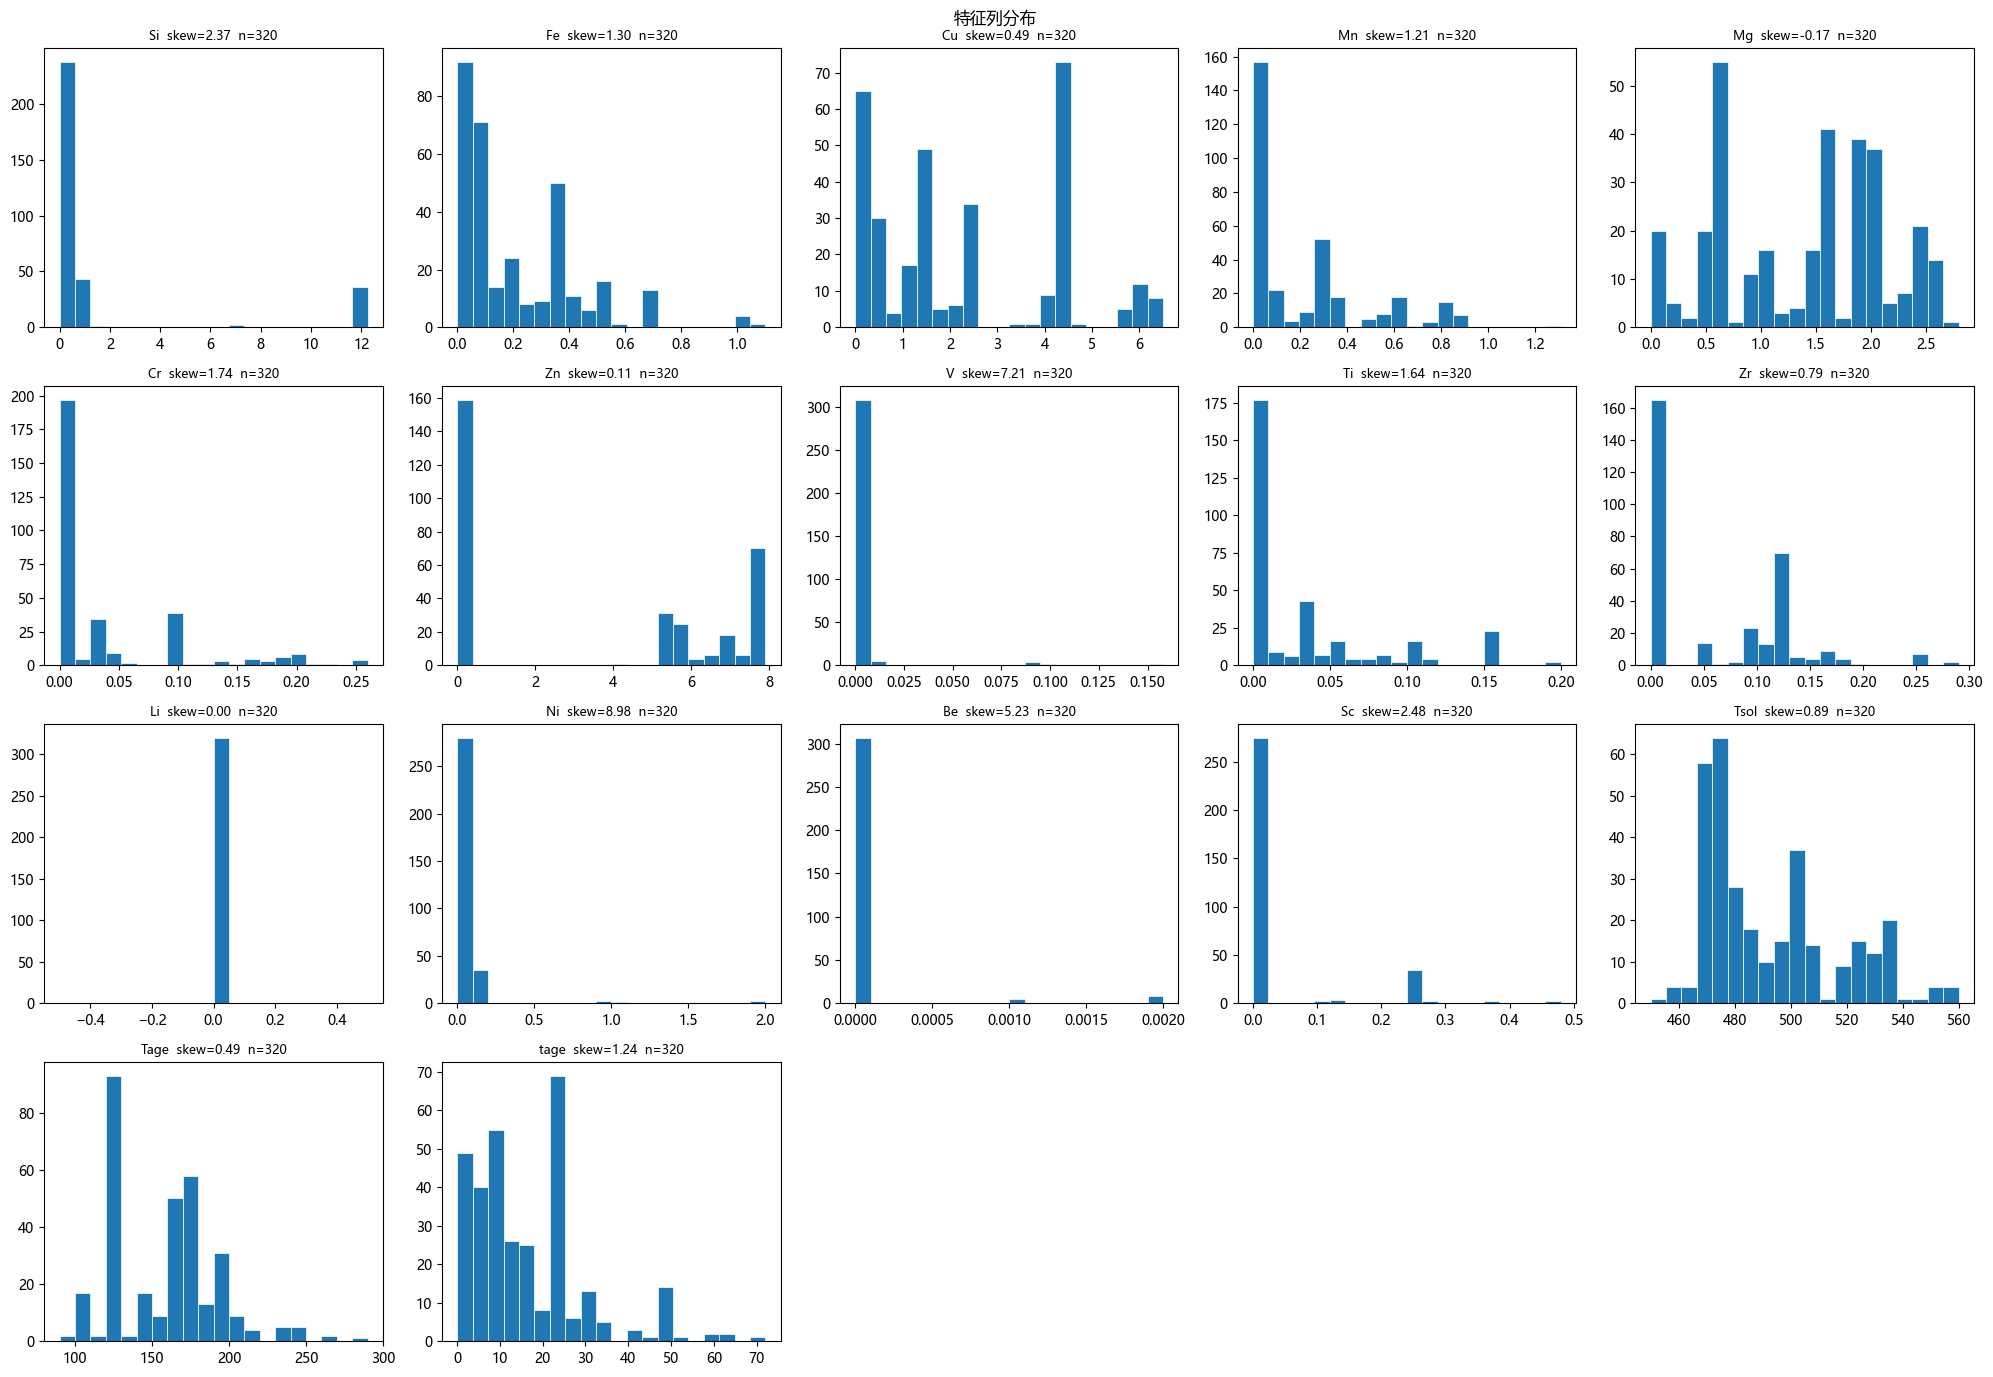

In [3]:
# Cell 2：特征分布图
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(features):
    data = df[col].dropna()
    axes[i].hist(data, bins=20, edgecolor='white', linewidth=0.5)
    axes[i].set_title(f'{col}  skew={data.skew():.2f}  n={len(data)}', fontsize=9)

for j in range(len(features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('特征列分布', fontsize=12)
plt.tight_layout()
plt.savefig('dist_features.png', dpi=150)
plt.show()

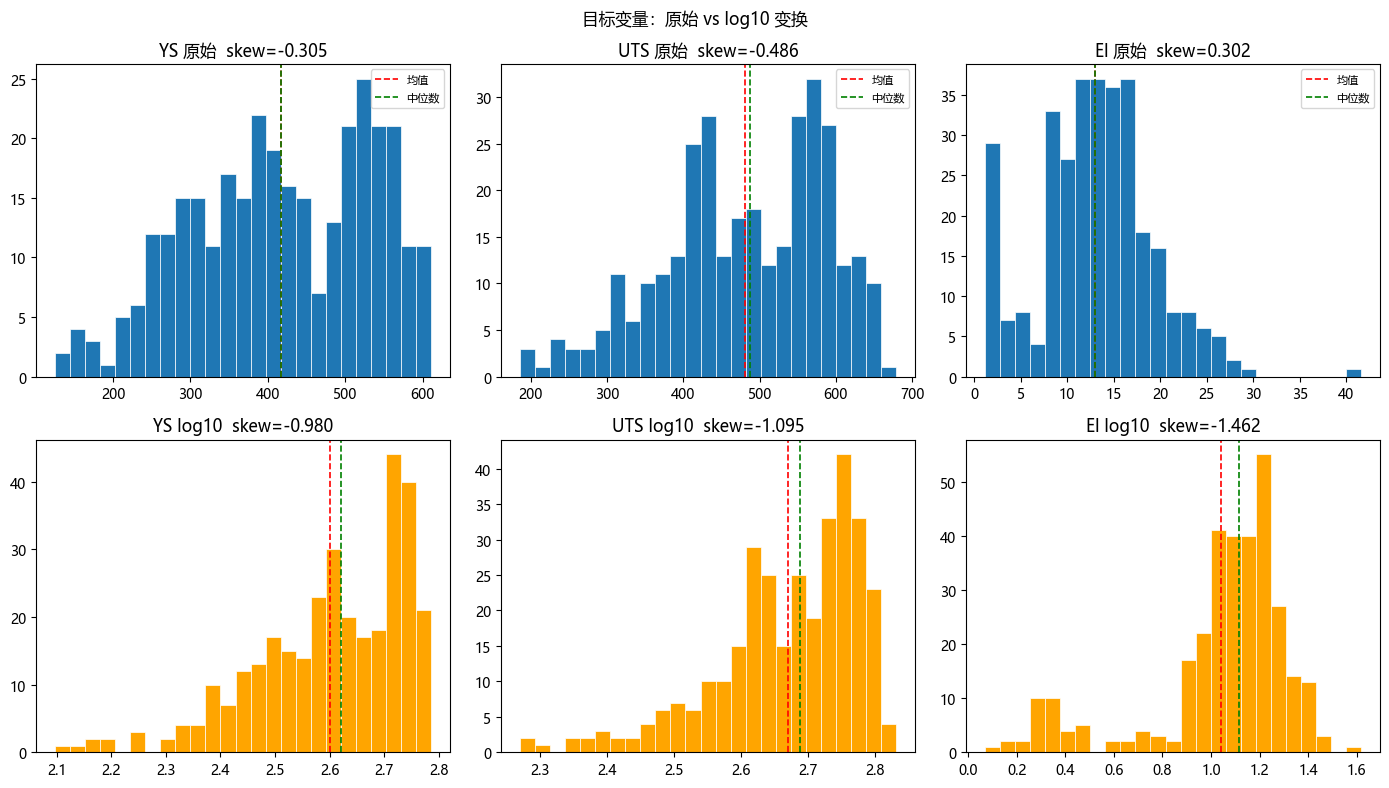

In [ ]:
# Cell 3：目标变量原始 vs log10
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(targets):
    data     = df[col].dropna()
    log_data = np.log10(data)

    axes[0, i].hist(data, bins=25, edgecolor='white', linewidth=0.5)
    axes[0, i].set_title(f'{col} raw  skew={data.skew():.3f}')
    axes[0, i].axvline(data.mean(),   color='r', ls='--', lw=1.2, label='均值')
    axes[0, i].axvline(data.median(), color='g', ls='--', lw=1.2, label='中位数')
    axes[0, i].legend(fontsize=8)

    axes[1, i].hist(log_data, bins=25, edgecolor='white',
                    linewidth=0.5, color='orange')
    axes[1, i].set_title(f'{col} log10  skew={log_data.skew():.3f}')
    axes[1, i].axvline(log_data.mean(),   color='r', ls='--', lw=1.2)
    axes[1, i].axvline(log_data.median(), color='g', ls='--', lw=1.2)

plt.suptitle('目标变量：原始 vs log10 变换', fontsize=12)
plt.tight_layout()
plt.savefig('dist_targets.png', dpi=150)
plt.show()

对数据集的特征变量和目标变量进行了分布评估。通过计算偏度系数和变异系数（CV）对各变量的分布特性进行量化分析。结果表明，目标变量 YS、UTS 和 El 的偏度分别为 -0.305、-0.486 和 0.302，均在 ±0.5 范围内，分布较为对称，无需进行对数变换。YS 和 UTS 呈现双峰分布特征，反映了数据集中存在两类性能水平的合金体系。对于成分特征，Ni、V、Be、Sc 等微量元素呈现高度稀疏分布（偏度 > 5），这是合金数据库的固有特性，由于后续建模采用树模型，对特征偏态不敏感，因此无需变换。固溶温度 Tsol 的变异系数为 0.048，几乎无变化，在后续特征重要性分析中需关注其贡献。Li 元素在全部样本中均为 0，予以删除。

In [5]:
print(f"Li 全部为0: {(df['Li'] == 0).all()}")
df = df.drop(columns=['Li'])
features = [f for f in features if f != 'Li']
print(f"删除Li后，特征数: {len(features)}")

Li 全部为0: True
删除Li后，特征数: 16
